NAME:Vishveshwari Yuvraj Patil.

Roll No:42

DIV:TY AIML(B)

PRN:2324000875

EXPERIMENT NO:6

Implement Image Forging Detect and Classify forged images using OpenCV and Python. Use Machine
learning technique.

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras import layers, models
import numpy as np
import tensorflow as tf

In [4]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
model= Sequential()

model.add(Conv2D(6, (5, 5), activation='relu',padding='same', input_shape=(28, 28, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(Conv2D(16, (5, 5), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(120, activation='relu'))
model.add(layers.Dense(84, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        94,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,086 (422.21 KB)

 Trainable params: 108,086 (422.21 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import numpy as np
x_train_processed = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_processed = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train_processed = np.concatenate([x_train_processed, x_train_processed, x_train_processed], axis=-1)
x_test_processed = np.concatenate([x_test_processed, x_test_processed, x_test_processed], axis=-1)

x_train_processed = x_train_processed.astype('float32') / 255.0
x_test_processed = x_test_processed.astype('float32') / 255.0

history = model.fit(x_train_processed, y_train, epochs=5, batch_size=32 , validation_data=(x_test_processed, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9978 - loss: 0.0068 - val_accuracy: 0.9877 - val_loss: 0.0673
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9981 - loss: 0.0068 - val_accuracy: 0.9890 - val_loss: 0.0642
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9974 - loss: 0.0087 - val_accuracy: 0.9891 - val_loss: 0.0522
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9982 - loss: 0.0058 - val_accuracy: 0.9882 - val_loss: 0.0846
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 32ms/step - accuracy: 0.9980 - loss: 0.0076 - val_accuracy: 0.9910 - val_loss: 0.0583


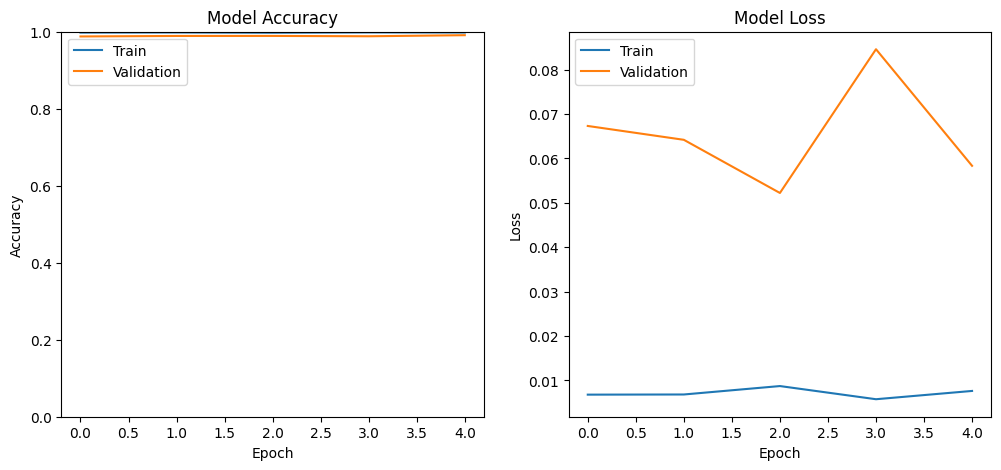

313/313 - 3s - 11ms/step - accuracy: 0.9910 - loss: 0.0583

Test accuracy: 0.9910
Test loss: 0.0583


In [10]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.ylim([0, 1])

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test_processed, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


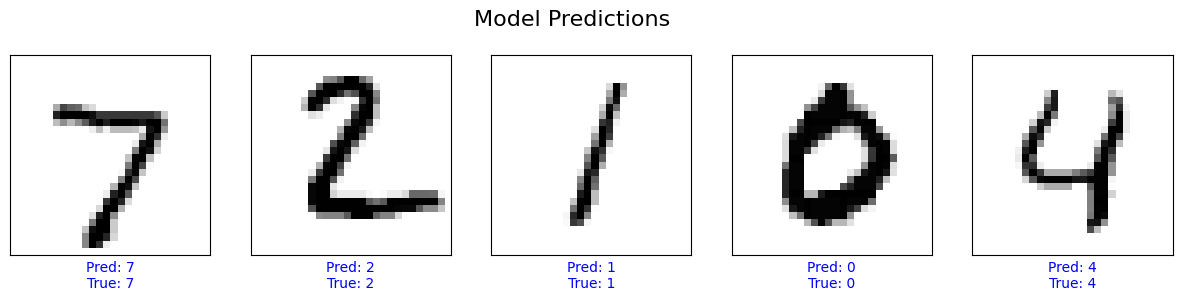

In [11]:
import numpy as np
import matplotlib.pyplot as plt # Ensure plt is imported here

# Define class_names for MNIST dataset
class_names = [str(i) for i in range(10)]

def plot_predictions(model_obj, title, num_images=5):
    # Use x_test_processed for test images
    predictions = model_obj.predict(x_test_processed[:num_images])
    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(x_test[i], cmap=plt.cm.binary) # Display original x_test for clarity

        predicted_label = np.argmax(predictions[i])
        true_label = y_test[i] # Use y_test for true labels

        color = 'blue' if predicted_label == true_label else 'red'
        plt.xlabel(f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}", color=color)
    plt.show()

plot_predictions(model, "Model Predictions")

# Removed plot_predictions(model2, ...) as model2 is not defined.